# Deep Learning for Comment Toxicity Detection

This notebook covers the complete workflow of building, training, and evaluating deep learning models for comment toxicity detection. We will implement and compare two recurrent architectures: 
- **Bidirectional LSTM (Long Short-Term Memory)**
- **Bidirectional GRU (Gated Recurrent Unit)**

The dataset contains online comments labeled with 6 toxicity categories: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, and `identity_hate`.

## 1. Imports and Setup

In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, Bidirectional, LSTM, GRU, Dense, GlobalMaxPool1D, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Version:", tf.__version__)
print("GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version: 2.21.0
GPUs Available: 0


## 2. Load and Explore the Dataset

In [2]:
# Load dataset
df = pd.read_csv('Dataset/train.csv')
print(f"Train dataset shape: {df.shape}")
df.head()

Train dataset shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Label Distributions:
 - toxic          : 15294 (9.58%)
 - severe_toxic   : 1595 (1.00%)
 - obscene        : 8449 (5.29%)
 - threat         : 478 (0.30%)
 - insult         : 7877 (4.94%)
 - identity_hate  : 1405 (0.88%)
 - Clean Comments : 143346 (89.83%)
 - Toxic Comments : 16225 (10.17%)


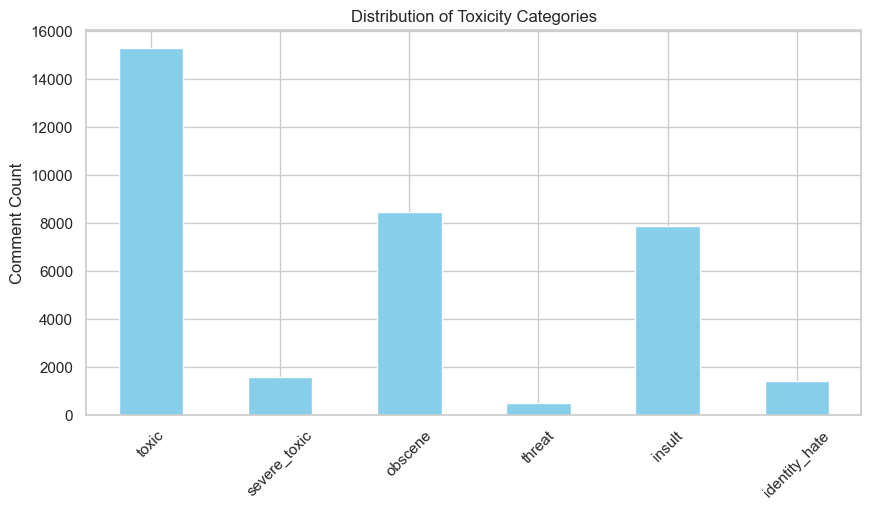

In [3]:
target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Calculate label frequencies
print("Label Distributions:")
for col in target_cols:
    count = df[col].sum()
    pct = df[col].mean() * 100
    print(f" - {col:15}: {count} ({pct:.2f}%)")

# Check if comments have no labels (clean comments)
df['any_toxicity'] = df[target_cols].any(axis=1)
clean_count = len(df) - df['any_toxicity'].sum()
print(f" - Clean Comments : {clean_count} ({clean_count/len(df)*100:.2f}%)")
print(f" - Toxic Comments : {df['any_toxicity'].sum()} ({df['any_toxicity'].mean()*100:.2f}%)")

# Plot the distributions
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
df[target_cols].sum().plot(kind='bar', color='skyblue')
plt.title('Distribution of Toxicity Categories')
plt.ylabel('Comment Count')
plt.xticks(rotation=45)
plt.show()

## 3. Text Preprocessing

In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "cannot ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Test cleaning
sample_text = "You're toxic, can't you understand?!"
print("Original:", sample_text)
print("Cleaned:", clean_text(sample_text))

Original: You're toxic, can't you understand?!
Cleaned: you are toxic cannot you understand


In [5]:
print("Preprocessing text column... (this may take a moment)")
df['cleaned_text'] = df['comment_text'].apply(clean_text)
df = df[df['cleaned_text'] != ""].reset_index(drop=True)
print("Cleaning completed.")

Preprocessing text column... (this may take a moment)
Cleaning completed.


## 4. Train-Test Split and Sampling for CPU

Because training recurrent models on CPU for 159,000 sentences is slow, we will sample **20,000 comments** to train our models in a reasonable timeframe (~3-5 minutes) while maintaining solid validation results. Increase this sample size or set to full dataset if GPU training is available.

In [6]:
sample_size = 20000

# Create structured sample to preserve balance
toxic_df = df[df['any_toxicity'] == True]
clean_df = df[df['any_toxicity'] == False]

toxic_ratio = len(toxic_df) / len(df)
toxic_sample_size = int(sample_size * toxic_ratio)
clean_sample_size = sample_size - toxic_sample_size

toxic_sample = toxic_df.sample(n=min(toxic_sample_size, len(toxic_df)), random_state=42)
clean_sample = clean_df.sample(n=min(clean_sample_size, len(clean_df)), random_state=42)

df_sample = pd.concat([toxic_sample, clean_sample]).sample(frac=1.0, random_state=42).reset_index(drop=True)

X = df_sample['cleaned_text'].to_numpy()
y = df_sample[target_cols].to_numpy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train comments: {len(X_train)}, Validation comments: {len(X_val)}")

Train comments: 16000, Validation comments: 4000


## 5. Text Tokenization and Vectorization

We use Keras `TextVectorization` layer to tokenize sentences into word sequences, mapping words to indices. We'll set the vocabulary size limit to `20,000` and maximum sequence length to `150` tokens.

In [7]:
max_tokens = 20000
max_len = 150

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=max_len,
    output_mode='int'
)

vectorizer.adapt(X_train)
print(f"Vocabulary size fitted: {len(vectorizer.get_vocabulary())} words")

Vocabulary size fitted: 20000 words


## 6. Model Architectures & Training

We define a factory function to compile the Bidirectional LSTM and Bidirectional GRU models. Both process the sequence of embedding vectors, global max pool, run through a dense layer, and predict 6 labels with sigmoid output probabilities.

In [8]:
def build_model(model_type, embedding_dim=128):
    inputs = tf.keras.Input(shape=(), dtype=tf.string)
    x = vectorizer(inputs)
    x = Embedding(input_dim=max_tokens, output_dim=embedding_dim)(x)
    
    if model_type == 'lstm':
        x = Bidirectional(LSTM(64, return_sequences=True))(x)
    elif model_type == 'gru':
        x = Bidirectional(GRU(64, return_sequences=True))(x)
    else:
        raise ValueError(f"Unknown model type: {model_type}")
        
    x = GlobalMaxPool1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(6, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs, outputs, name=f"Bi_{model_type.upper()}_Toxicity")
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy')]
    )
    return model

In [9]:
lstm_model = build_model('lstm')
lstm_model.summary()

Model: "Bi_LSTM_Toxicity"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 150)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,462 (10.18 MB)

 Trainable params: 2,667,462 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
epochs = 50
batch_size = 64

print("Training Bidirectional LSTM model...")
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Training Bidirectional LSTM model...
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - binary_accuracy: 0.9573 - loss: 0.1574 - val_binary_accuracy: 0.9700 - val_loss: 0.0898
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - binary_accuracy: 0.9774 - loss: 0.0662 - val_binary_accuracy: 0.9799 - val_loss: 0.0568
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - binary_accuracy: 0.9835 - loss: 0.0443 - val_binary_accuracy: 0.9800 - val_loss: 0.0602
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - binary_accuracy: 0.9860 - loss: 0.0371 - val_binary_accuracy: 0.9780 - val_loss: 0.0648
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - binary_accuracy: 0.9876 - loss: 0.0321 - val_binary_accuracy: 0.9788 - val_loss: 0.0713


In [11]:
gru_model = build_model('gru')
gru_model.summary()

Model: "Bi_GRU_Toxicity"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 150)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 150, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,643,142 (10.08 MB)

 Trainable params: 2,643,142 (10.08 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
print("Training Bidirectional GRU model...")
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Training Bidirectional GRU model...
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - binary_accuracy: 0.9636 - loss: 0.1390 - val_binary_accuracy: 0.9795 - val_loss: 0.0605
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - binary_accuracy: 0.9810 - loss: 0.0549 - val_binary_accuracy: 0.9804 - val_loss: 0.0567
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - binary_accuracy: 0.9844 - loss: 0.0425 - val_binary_accuracy: 0.9790 - val_loss: 0.0589
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - binary_accuracy: 0.9866 - loss: 0.0351 - val_binary_accuracy: 0.9796 - val_loss: 0.0701
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - binary_accuracy: 0.9884 - loss: 0.0308 - val_binary_accuracy: 0.9778 - val_loss: 0.0682


## 7. Model History and Plotting Learning Curves

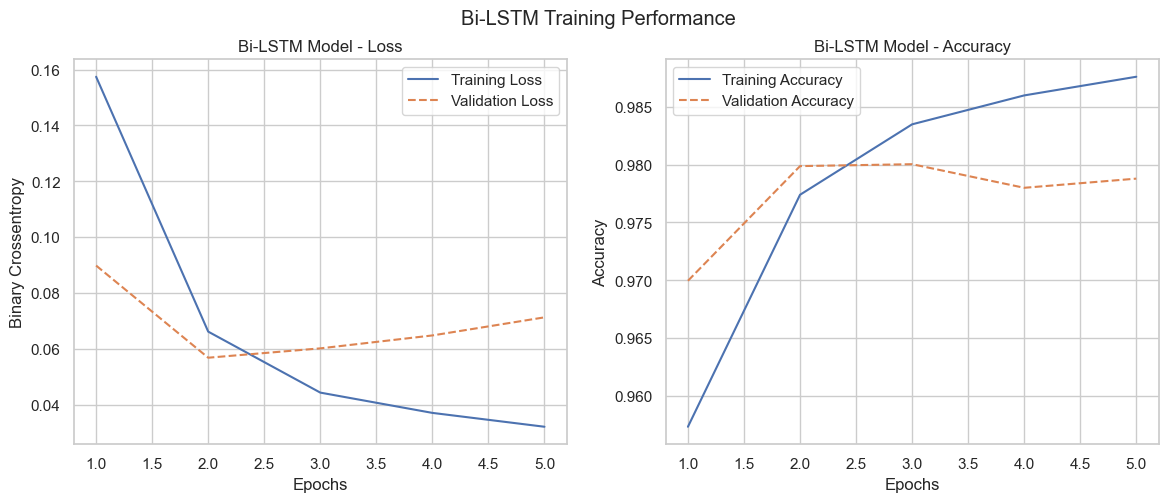

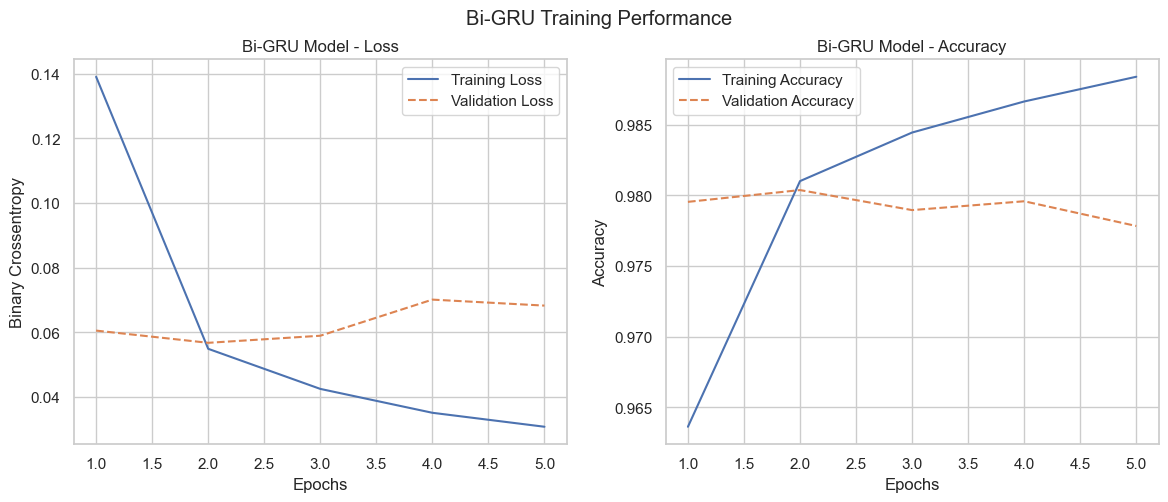

In [13]:
def plot_curves(history, name):
    # Handle different metrics in history dictionary (binary_accuracy vs accuracy)
    acc_key = 'binary_accuracy' if 'binary_accuracy' in history.history else 'accuracy'
    val_acc_key = 'val_binary_accuracy' if 'val_binary_accuracy' in history.history else 'val_accuracy'
    
    epochs_range = range(1, len(history.history['loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(epochs_range, history.history['loss'], label='Training Loss')
    ax1.plot(epochs_range, history.history['val_loss'], label='Validation Loss', linestyle='--')
    ax1.set_title(f'{name} Model - Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Binary Crossentropy')
    ax1.legend()
    
    ax2.plot(epochs_range, history.history[acc_key], label='Training Accuracy')
    ax2.plot(epochs_range, history.history[val_acc_key], label='Validation Accuracy', linestyle='--')
    ax2.set_title(f'{name} Model - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    plt.suptitle(f'{name} Training Performance')
    plt.show()

plot_curves(lstm_history, "Bi-LSTM")
plot_curves(gru_history, "Bi-GRU")

## 8. Evaluation and Comparison

In [14]:
def evaluate_model(model, name):
    print(f"\n{'='*20} Evaluation: {name} {'='*20}")
    # Get probabilities
    preds = model.predict(X_val, batch_size=128)
    # Threshold to binary predictions
    preds_bin = (preds >= 0.5).astype(int)
    
    # Compute ROC-AUC per class and overall macro
    aucs = []
    for i, col in enumerate(target_cols):
        if len(np.unique(y_val[:, i])) > 1:
            auc_cls = roc_auc_score(y_val[:, i], preds[:, i])
        else:
            auc_cls = 0.5
        aucs.append(auc_cls)
    
    macro_auc = np.mean(aucs)
    try:
        micro_auc = roc_auc_score(y_val, preds, average='micro')
    except:
        micro_auc = 0.5
    
    print(f"Overall Macro ROC-AUC : {macro_auc:.4f}")
    print(f"Overall Micro ROC-AUC : {micro_auc:.4f}")
    
    # Macro averages for P, R, F1
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, preds_bin, average='macro', zero_division=0)
    print(f"Overall Macro Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")
    
    # Per-class scores
    print("\nScores by Toxicity Subcategory:")
    for i, col in enumerate(target_cols):
        p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(y_val[:, i], preds_bin[:, i], average='binary', zero_division=0)
        print(f" - {col:15} | AUC: {aucs[i]:.4f} | Precision: {p_cls:.4f} | Recall: {r_cls:.4f} | F1: {f1_cls:.4f}")

evaluate_model(lstm_model, "Bi-LSTM")
evaluate_model(gru_model, "Bi-GRU")


==================== Evaluation: Bi-LSTM ====================
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
Overall Macro ROC-AUC : 0.9636
Overall Micro ROC-AUC : 0.9777
Overall Macro Precision: 0.5132 | Recall: 0.3141 | F1-Score: 0.3643

Scores by Toxicity Subcategory:
 - toxic           | AUC: 0.9645 | Precision: 0.8571 | Recall: 0.7049 | F1: 0.7736
 - severe_toxic    | AUC: 0.9852 | Precision: 0.6667 | Recall: 0.0606 | F1: 0.1111
 - obscene         | AUC: 0.9815 | Precision: 0.7987 | Recall: 0.6000 | F1: 0.6852
 - threat          | AUC: 0.9285 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
 - insult          | AUC: 0.9740 | Precision: 0.7569 | Recall: 0.5190 | F1: 0.6158
 - identity_hate   | AUC: 0.9482 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000

==================== Evaluation: Bi-GRU ====================
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
Overall Macro ROC-AUC : 0.9627
Overall Micro ROC-AUC : 0.9775
Overall Macro Precision: 0.5008 | Recall: 0.2993 | F1-Score: 0.3514

Sco

## 9. Save Models to Disk for Streamlit Deployment

In [15]:
# Export LSTM/GRU files
os.makedirs('models', exist_ok=True)
lstm_model.save('models/bi_lstm_model.keras')
gru_model.save('models/bi_gru_model.keras')
print("LSTM and GRU Keras models saved to models/ directory successfully!")

LSTM and GRU Keras models saved to models/ directory successfully!


## 10. Transformer-based Model (BERT)

In this section, we implement and fine-tune a pre-trained Transformer model (BERT) for comment toxicity. We use a lightweight variant **`prajjwal1/bert-tiny`** (which is only ~17MB and trains quickly on CPU) and Hugging Face's `transformers` library, tokenizing the text inputs separately using a BERT tokenizer, and building a multi-label classification head.

In [16]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

bert_name = 'prajjwal1/bert-tiny'
print(f"Loading tokenizer and pre-trained model: {bert_name}...")
tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = TFAutoModelForSequenceClassification.from_pretrained(
    bert_name,
    num_labels=6,
    problem_type="multi_label_classification",
    from_pt=True
)

c:\Users\Yoga\Documents\project\Deep Learning for Comment Toxicity Detection with Streamlit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer and pre-trained model: prajjwal1/bert-tiny...




TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should p

In [17]:
print("Tokenizing inputs for BERT...")
X_train_bert = tokenizer(list(X_train), padding='max_length', truncation=True, max_length=150, return_tensors='np')
X_val_bert = tokenizer(list(X_val), padding='max_length', truncation=True, max_length=150, return_tensors='np')

train_inputs = {
    "input_ids": X_train_bert["input_ids"],
    "attention_mask": X_train_bert["attention_mask"]
}
val_inputs = {
    "input_ids": X_val_bert["input_ids"],
    "attention_mask": X_val_bert["attention_mask"]
}

Tokenizing inputs for BERT...


In [18]:
# Compile BERT Model
import tf_keras as tfk
optimizer = tfk.optimizers.Adam(learning_rate=5e-5)
bert_model.compile(
    optimizer=optimizer,
    loss=tfk.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tfk.metrics.BinaryAccuracy(name='binary_accuracy')]
)
bert_model.summary()

Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  4385920   
                                                                 
 dropout_7 (Dropout)         multiple                  0         
                                                                 
 classifier (Dense)          multiple                  774       
                                                                 
Total params: 4386694 (16.73 MB)
Trainable params: 4386694 (16.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
print("Fine-tuning BERT Model...")
early_stop = tfk.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
bert_history = bert_model.fit(
    train_inputs, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(val_inputs, y_val),
    callbacks=[early_stop],
    verbose=1
)

Fine-tuning BERT Model...
Epoch 1/3

250/250 [==============================] - 46s 159ms/step - loss: 0.3753 - binary_accuracy: 0.9629 - val_loss: 0.2222 - val_binary_accuracy: 0.9640
Epoch 2/3
250/250 [==============================] - 40s 159ms/step - loss: 0.1889 - binary_accuracy: 0.9629 - val_loss: 0.1615 - val_binary_accuracy: 0.9640
Epoch 3/3
250/250 [==============================] - 40s 158ms/step - loss: 0.1238 - binary_accuracy: 0.9661 - val_loss: 0.1010 - val_binary_accuracy: 0.9671


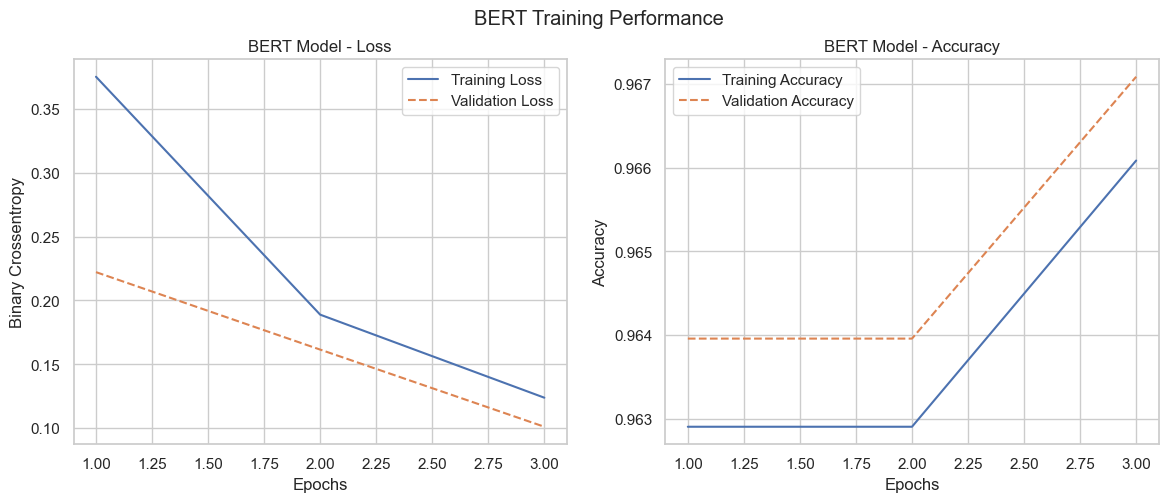

In [20]:
plot_curves(bert_history, "BERT")

In [21]:
print("Evaluating BERT Model on validation set...")
bert_preds_logits = bert_model.predict(val_inputs, batch_size=64)
logits = bert_preds_logits.logits if hasattr(bert_preds_logits, 'logits') else bert_preds_logits
bert_preds = tf.nn.sigmoid(logits).numpy()
bert_preds_bin = (bert_preds >= 0.5).astype(int)

aucs = []
for i, col in enumerate(target_cols):
    if len(np.unique(y_val[:, i])) > 1:
        auc_cls = roc_auc_score(y_val[:, i], bert_preds[:, i])
    else:
        auc_cls = 0.5
    aucs.append(auc_cls)

macro_auc = np.mean(aucs)
try:
    micro_auc = roc_auc_score(y_val, bert_preds, average='micro')
except:
    micro_auc = 0.5

print(f"Overall Macro ROC-AUC : {macro_auc:.4f}")
print(f"Overall Micro ROC-AUC : {micro_auc:.4f}")

precision, recall, f1, _ = precision_recall_fscore_support(y_val, bert_preds_bin, average='macro', zero_division=0)
print(f"Overall Macro Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")

print("\nScores by Toxicity Subcategory:")
for i, col in enumerate(target_cols):
    p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(y_val[:, i], bert_preds_bin[:, i], average='binary', zero_division=0)
    print(f" - {col:15} | AUC: {aucs[i]:.4f} | Precision: {p_cls:.4f} | Recall: {r_cls:.4f} | F1: {f1_cls:.4f}")

Evaluating BERT Model on validation set...
63/63 [==============================] - 3s 38ms/step
Overall Macro ROC-AUC : 0.9561
Overall Micro ROC-AUC : 0.9602
Overall Macro Precision: 0.4615 | Recall: 0.1782 | F1-Score: 0.2565

Scores by Toxicity Subcategory:
 - toxic           | AUC: 0.9596 | Precision: 0.9868 | Recall: 0.4071 | F1: 0.5764
 - severe_toxic    | AUC: 0.9861 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
 - obscene         | AUC: 0.9659 | Precision: 0.9765 | Recall: 0.4049 | F1: 0.5724
 - threat          | AUC: 0.9412 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
 - insult          | AUC: 0.9689 | Precision: 0.8060 | Recall: 0.2571 | F1: 0.3899
 - identity_hate   | AUC: 0.9150 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


In [22]:
# Save BERT model
bert_model.save_pretrained('models/bert_model')
tokenizer.save_pretrained('models/bert_model')
print("BERT model and tokenizer saved to models/bert_model/ successfully!")

BERT model and tokenizer saved to models/bert_model/ successfully!
